In [1]:
import pickle
with open('..//data//dbpedia_phrases_10000.pickle', 'rb') as handle:
    phrases = pickle.load(handle)
with open('..//data//dbpedia_contexts_10000.pickle', 'rb') as handle:
    contexts = pickle.load(handle)

In [2]:
from selmr import SELMR, LanguageMultisets

selmr = SELMR(
    multisets=LanguageMultisets(phrases, contexts, None)
)

In [33]:
word = "deal"
contexts = [c for c in selmr.contexts(word, topn=40)]
c = dict()
for context in contexts:
    c[context] = selmr.most_similar(
        phrase=word,
        context=context,
        topcontexts=None,
        topphrases=None,
        topn=None
    ).keys()

In [34]:
from selmr import jaccard_index, containment_index, weighted_jaccard_index
import numpy as np

l = list(c.keys())
d = np.zeros([len(l), len(l)])
for i, key1 in enumerate(l):
    for j, key2 in enumerate(l):
        d[i, j] =  1 - jaccard_index(c[key1], c[key2])

In [35]:
d

array([[0.        , 0.99319066, 0.9968119 , ..., 0.99246704, 0.99890591,
        0.95177165],
       [0.99319066, 0.        , 0.75206612, ..., 0.99272727, 0.99173554,
        0.99259259],
       [0.9968119 , 0.75206612, 0.        , ..., 0.99459459, 0.96666667,
        0.98882682],
       ...,
       [0.99246704, 0.99272727, 0.99459459, ..., 0.        , 0.99358974,
        0.98344371],
       [0.99890591, 0.99173554, 0.96666667, ..., 0.99358974, 0.        ,
        0.99337748],
       [0.95177165, 0.99259259, 0.98882682, ..., 0.98344371, 0.99337748,
        0.        ]])

In [36]:
# import scipy
# d = scipy.spatial.distance.squareform(d)

C:\Users\wjwil\AppData\Local\Temp\ipykernel_12520\406021759.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clusters = hierarchy.linkage(d)


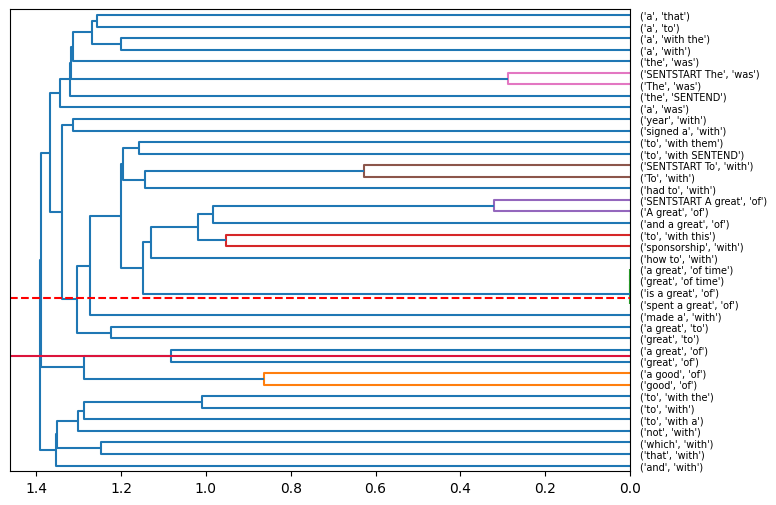

In [37]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt

clusters = hierarchy.linkage(d)
plt.figure(figsize=(8, 6))
dendrogram = hierarchy.dendrogram(clusters, labels=l, leaf_font_size=7, orientation="left", show_leaf_counts=True)
plt.axhline(150, color='red', linestyle='--')
plt.axhline(100, color='crimson')